In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
adam_path = "/home/yuxuan/code/prose/fluids/src/checkpoint/save/1to1_auto_41/evals_all/outputs/incom_ns_arena.npz"
d = np.load(adam_path)
output_adam = d["output"]
target = d["target"]
errors_adam = d["errors"]

In [ ]:
output_adam.shape

(50, 10, 128, 128, 3)

In [6]:
muon_path = (
    "/home/yuxuan/code/time/time-series/src/checkpoint/save/bcat_muon_all_1/evals_all/outputs/incom_ns_arena.npz"
)
d2 = np.load(muon_path)
output_muon = d2["output"]
target = d2["target"]
errors_muon = d2["errors"]

In [7]:
output_muon.shape

(50, 10, 128, 128, 3)

In [ ]:
# ----- FFT Power Spectrum -----
def compute_power_spectrum(field_2d):
    field_hat = np.fft.fft2(field_2d, norm="ortho")
    field_hat_shifted = np.fft.fftshift(field_hat)
    return np.abs(field_hat_shifted) ** 2


# ----- Radial Average -----
def radial_profile(power_2d):
    Nx, Ny = power_2d.shape
    x = np.arange(-Nx // 2, Nx // 2)
    y = np.arange(-Ny // 2, Ny // 2)
    X, Y = np.meshgrid(x, y, indexing="ij")
    R = np.sqrt(X**2 + Y**2).astype(int)

    max_radius = min(Nx, Ny) // 2
    radial_sum = np.bincount(R.ravel(), weights=power_2d.ravel())
    radial_count = np.bincount(R.ravel())
    radial_mean = radial_sum / (radial_count + 1e-8)
    return radial_mean[:max_radius]


# ----- Average 1D Spectrum from Batch+Time -----
def compute_average_spectrum(data, channel):
    B, T, Nx, Ny, _ = data.shape
    spectra = []
    for b in range(B):
        for t in range(T):
            field = data[b, t, :, :, channel]
            ps_2d = compute_power_spectrum(field)
            ps_1d = radial_profile(ps_2d)
            spectra.append(ps_1d)
    spectra = np.stack(spectra, axis=0)
    return np.mean(spectra, axis=0)


# ----- Relative Error in Frequency Domain -----
def compute_relative_spectrum_error(model, target, channel):
    spec_model = compute_average_spectrum(model, channel)
    spec_target = compute_average_spectrum(target, channel)
    eps = 1e-10
    return np.linalg.norm(spec_model - spec_target) / (np.linalg.norm(spec_target) + eps)


# ----- Main Comparison Plot -----
def compare_model_to_target(model, target, channel, label="Model"):
    spec_model = compute_average_spectrum(model, channel)
    spec_target = compute_average_spectrum(target, channel)
    rel_error = compute_relative_spectrum_error(model, target, channel)
    k = np.arange(len(spec_model))

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Power spectrum comparison
    axs[0].loglog(k, spec_target + 1e-10, label="Target")
    axs[0].loglog(k, spec_model + 1e-10, label=label)
    axs[0].set_title(f"Power Spectrum (Channel {channel})")
    axs[0].set_xlabel("Wave number (k)")
    axs[0].set_ylabel("Power")
    axs[0].legend()
    # axs[0].grid(True, which='both', ls='--')

    # Relative spectrum error
    axs[1].loglog(k, rel_error + 1e-10, color="r")
    axs[1].set_title(f"Relative Spectrum Error (Channel {channel})")
    axs[1].set_xlabel("Wave number (k)")
    axs[1].set_ylabel("Relative Error")
    # axs[1].grid(True, which='both', ls='--')

    plt.tight_layout()
    plt.show()

In [ ]:
# ---------- Standardization ----------
def compute_channel_mean_std(data):
    # data: (B, T, Nx, Ny, C)
    mean = data.mean(axis=(0, 1, 2, 3))  # shape (C,)
    std = data.std(axis=(0, 1, 2, 3)) + 1e-8  # avoid divide by zero
    return mean, std


def standardize_by_target(model, target_mean, target_std):
    return (model - target_mean[None, None, None, None, :]) / target_std[None, None, None, None, :]


def compare_two_models_to_target(model1, model2, target, channel, label1="Model 1", label2="Model 2"):
    target_mean, target_std = compute_channel_mean_std(target)
    model1_std = standardize_by_target(model1, target_mean, target_std)
    model2_std = standardize_by_target(model2, target_mean, target_std)
    target_std = standardize_by_target(target, target_mean, target_std)

    spec1 = compute_average_spectrum(model1_std, channel)
    spec2 = compute_average_spectrum(model2_std, channel)
    spec_target = compute_average_spectrum(target_std, channel)

    rel_err1 = np.abs(spec1 - spec_target) / (np.abs(spec_target) + 1e-10)
    rel_err2 = np.abs(spec2 - spec_target) / (np.abs(spec_target) + 1e-10)

    k = np.arange(len(spec1))

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    # Power spectra comparison
    axs[0].plot(k[5:], spec_target[5:] + 1e-10, label="Target", color="black", lw=2)
    axs[0].plot(k[5:], spec1[5:] + 1e-10, label=label1, linestyle="--")
    axs[0].plot(k[5:], spec2[5:] + 1e-10, label=label2, linestyle=":")
    axs[0].set_title(f"Power Spectrum (Channel {channel})")
    axs[0].set_yscale("log")
    axs[0].set_xlabel("Wave number (k)")
    axs[0].set_ylabel("Power")
    axs[0].legend()
    # axs[0].grid(True, which='both', ls='--')

    # Relative error comparison
    axs[1].plot(k[5:], rel_err1[5:] + 1e-10, label=f"{label1} Error", linestyle="--")
    axs[1].plot(k[5:], rel_err2[5:] + 1e-10, label=f"{label2} Error", linestyle=":")
    axs[1].set_title(f"Relative Spectrum Error (Channel {channel})")
    axs[1].set_xlabel("Wave number (k)")
    axs[1].set_ylabel("Relative Error")
    axs[0].set_yscale("log")
    axs[1].legend()
    # axs[1].grid(True, which='both', ls='--')

    plt.tight_layout()
    plt.show()

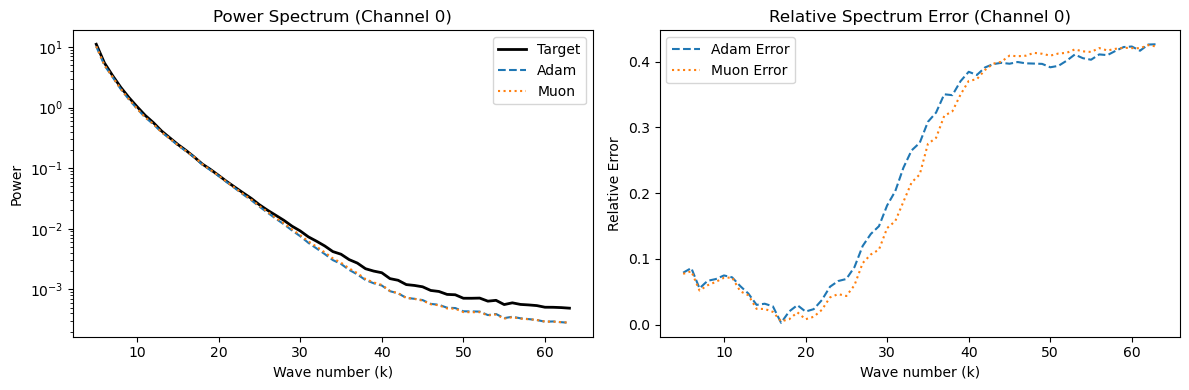

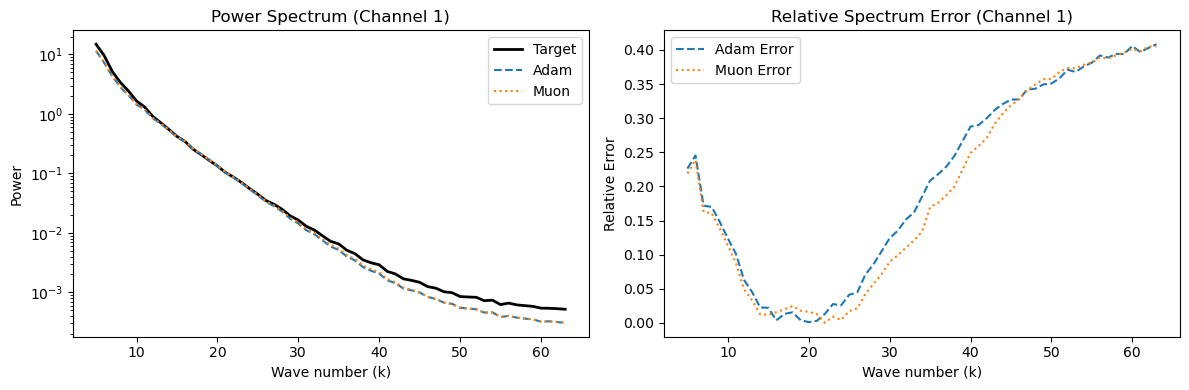

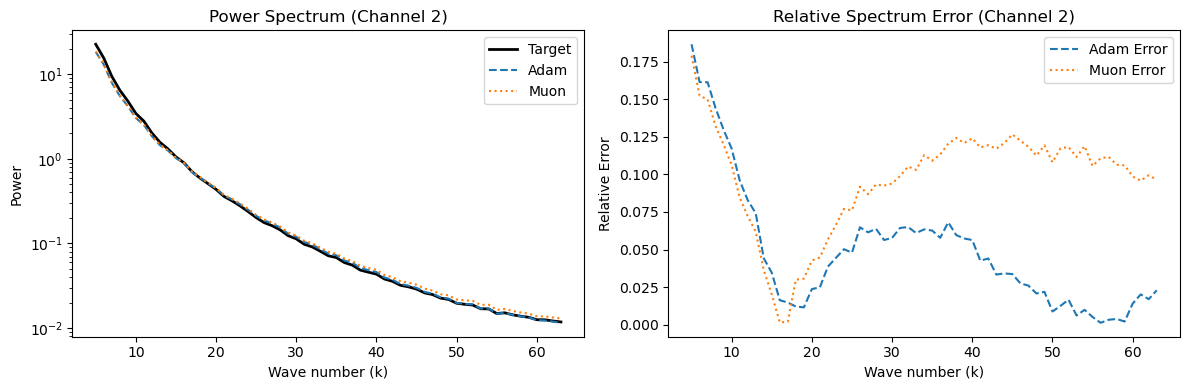

In [33]:
for i in range(3):
    compare_two_models_to_target(output_adam, output_muon, target, channel=i, label1="Adam", label2="Muon")

In [ ]:
# def plot_average_spectrum_error_both_models(model1, model2, target, label1="Model 1", label2="Model 2"):
#     spec_model1 = compute_average_spectrum_all_channels(model1)
#     spec_model2 = compute_average_spectrum_all_channels(model2)
#     spec_target = compute_average_spectrum_all_channels(target)
#     eps = 1e-10

#     rel_error1 = np.abs(spec_model1 - spec_target) / (spec_target + eps)
#     rel_error2 = np.abs(spec_model2 - spec_target) / (spec_target + eps)
#     k = np.arange(len(spec_target))

#     plt.figure(figsize=(8, 5))
#     plt.loglog(k, rel_error1 + eps, label=f"{label1} Relative Spectrum Error", linestyle='--')
#     plt.loglog(k, rel_error2 + eps, label=f"{label2} Relative Spectrum Error", linestyle=':')
#     plt.xlabel("Wave number (k)")
#     plt.ylabel("Relative Error")
#     plt.title("Average Relative Spectrum Error Across All Channels")
#     plt.legend()
#     # plt.grid(True, which='both', ls='--')
#     plt.tight_layout()
#     plt.show()

# plot_average_spectrum_error_both_models(output_adam, output_muon, target, label1="Adam", label2="Muon")